<a href="https://colab.research.google.com/github/esther033/2026-1_CV/blob/main/hw3/01_experiment_A_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실험 A — 손실 함수 비교: CrossEntropy vs MSE (with softmax)

## 실험 목표
- **CrossEntropy Loss**와 **MSE Loss**가 분류 학습 성능에 미치는 차이를 정량적으로 분석한다.
- 학습 곡선의 **수렴 속도**, **최종 정확도**, **gradient 흐름의 안정성**을 비교한다.
- MSE 사용 시 발생하는 **gradient vanishing 문제**를 시각화한다.

## 실험 조건
| 항목 | 값 |
|---|---|
| 데이터셋 | Fashion-MNIST (메인), Digits (보조) |
| 네트워크 | MLP: `input → 256 → 128 → num_classes`, ReLU |
| 옵티마이저 | Adam, lr=0.001 |
| Epoch | 30 (Fashion-MNIST), 50 (Digits) |
| Batch size | 128 |
| 변경 변수 | 손실 함수 (CrossEntropy / MSE+softmax+one-hot) |
| 시드 | 42 |

## 손실 함수 적용 방식
```python
# CrossEntropy: 내부적으로 log_softmax + NLLLoss 수행
loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(logits, targets)             # targets는 정수 라벨

# MSE: 직접 softmax 적용 + one-hot encoding 필요
loss_fn = nn.MSELoss()
probs = torch.softmax(logits, dim=1)
targets_onehot = F.one_hot(targets, num_classes).float()
loss = loss_fn(probs, targets_onehot)
```
> **주의**: MSE에 softmax를 적용하지 않으면 출력 범위가 unbounded라서 학습이 불안정해진다 (질문 A-4 답변용 근거).


## 0. 셋업

In [1]:
# Google Drive 마운트 + common_utils.py 경로 추가
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/CV_hw#3')
from common_utils import (
    set_seed, get_device, fit, evaluate,
    plot_loss_acc_curves, plot_gradient_flow,
    summarize_histories
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

set_seed(42)
device = get_device()
print("Device:", device)


Mounted at /content/drive
Device: cuda


## 1. 데이터셋 준비

- **Fashion-MNIST**: 28×28 흑백 이미지, 10 클래스 (60000 train / 10000 test)
- **Digits (sklearn)**: 8×8 숫자 이미지, 10 클래스 (1797개) — 보조 실험용


In [2]:
# ----- Fashion-MNIST -----
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),                  # [0,1] 범위로 변환
    transforms.Lambda(lambda x: x.view(-1)) # 28x28 → 784 flatten
])

fmnist_train = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
fmnist_test  = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)
fmnist_train_loader = DataLoader(fmnist_train, batch_size=128, shuffle=True)
fmnist_test_loader  = DataLoader(fmnist_test,  batch_size=256, shuffle=False)

print(f"Fashion-MNIST train: {len(fmnist_train)}, test: {len(fmnist_test)}")


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 175kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.16MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.0MB/s]

Fashion-MNIST train: 60000, test: 10000


In [3]:
# ----- Digits (sklearn) -----
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

X, y = load_digits(return_X_y=True)
X = X / 16.0
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
digits_train_loader = DataLoader(
    TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                  torch.tensor(y_tr, dtype=torch.long)),
    batch_size=64, shuffle=True
)
digits_test_loader = DataLoader(
    TensorDataset(torch.tensor(X_te, dtype=torch.float32),
                  torch.tensor(y_te, dtype=torch.long)),
    batch_size=64
)
print(f"Digits train: {len(X_tr)}, test: {len(X_te)}")


Digits train: 1437, test: 360


## 2. 모델 정의


- Fashion-MNIST: `784 → 256 → 128 → 10`
- Digits: `64 → 256 → 128 → 10`


In [4]:
def make_mlp(input_size: int, num_classes: int = 10):
    """
    실험 A 공통 MLP 모델.
    네트워크 구조: input → 256 → 128 → num_classes (활성화 ReLU)
    """
    return nn.Sequential(
        nn.Linear(input_size, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, num_classes),
    )


## 3. Fashion-MNIST 실험

In [5]:
EPOCHS_FMNIST = 30
LR = 1e-3

# ----- (1) CrossEntropy -----
set_seed(42)
model_ce = make_mlp(784, 10).to(device)
opt_ce   = torch.optim.Adam(model_ce.parameters(), lr=LR)
print(">>> Fashion-MNIST + CrossEntropy")
hist_fmnist_ce = fit(
    model_ce, fmnist_train_loader, fmnist_test_loader,
    nn.CrossEntropyLoss(), opt_ce, device,
    epochs=EPOCHS_FMNIST, loss_type='ce', log_every=5
)


>>> Fashion-MNIST + CrossEntropy
[  1/30] train_loss=0.5703 train_acc=80.05% test_loss=0.4423 test_acc=84.41% grad_norm=1.8628 lr=0.00100
[  5/30] train_loss=0.2978 train_acc=89.02% test_loss=0.3443 test_acc=87.93% grad_norm=0.9210 lr=0.00100
[ 10/30] train_loss=0.2363 train_acc=91.04% test_loss=0.3228 test_acc=88.75% grad_norm=0.8244 lr=0.00100
[ 15/30] train_loss=0.1971 train_acc=92.53% test_loss=0.3226 test_acc=88.85% grad_norm=0.7917 lr=0.00100
[ 20/30] train_loss=0.1631 train_acc=93.73% test_loss=0.3358 test_acc=89.57% grad_norm=0.7711 lr=0.00100
[ 25/30] train_loss=0.1393 train_acc=94.79% test_loss=0.3806 test_acc=89.40% grad_norm=0.7594 lr=0.00100
[ 30/30] train_loss=0.1208 train_acc=95.42% test_loss=0.3892 test_acc=89.57% grad_norm=0.7816 lr=0.00100


In [6]:
# ----- (2) MSE (with softmax + one-hot) -----
set_seed(42)  # 같은 초기화 보장
model_mse = make_mlp(784, 10).to(device)
opt_mse   = torch.optim.Adam(model_mse.parameters(), lr=LR)
print(">>> Fashion-MNIST + MSE (with softmax)")
hist_fmnist_mse = fit(
    model_mse, fmnist_train_loader, fmnist_test_loader,
    nn.MSELoss(), opt_mse, device,
    epochs=EPOCHS_FMNIST, loss_type='mse', log_every=5
)


>>> Fashion-MNIST + MSE (with softmax)
[  1/30] train_loss=0.0288 train_acc=79.98% test_loss=0.0241 test_acc=83.57% grad_norm=0.0926 lr=0.00100
[  5/30] train_loss=0.0163 train_acc=88.86% test_loss=0.0186 test_acc=87.14% grad_norm=0.0470 lr=0.00100
[ 10/30] train_loss=0.0136 train_acc=90.82% test_loss=0.0173 test_acc=88.02% grad_norm=0.0423 lr=0.00100
[ 15/30] train_loss=0.0119 train_acc=92.08% test_loss=0.0165 test_acc=88.82% grad_norm=0.0415 lr=0.00100
[ 20/30] train_loss=0.0106 train_acc=93.03% test_loss=0.0160 test_acc=89.24% grad_norm=0.0419 lr=0.00100
[ 25/30] train_loss=0.0093 train_acc=93.97% test_loss=0.0166 test_acc=88.93% grad_norm=0.0400 lr=0.00100
[ 30/30] train_loss=0.0083 train_acc=94.67% test_loss=0.0158 test_acc=89.70% grad_norm=0.0403 lr=0.00100


### 3.1 학습 곡선 비교 (Fashion-MNIST)

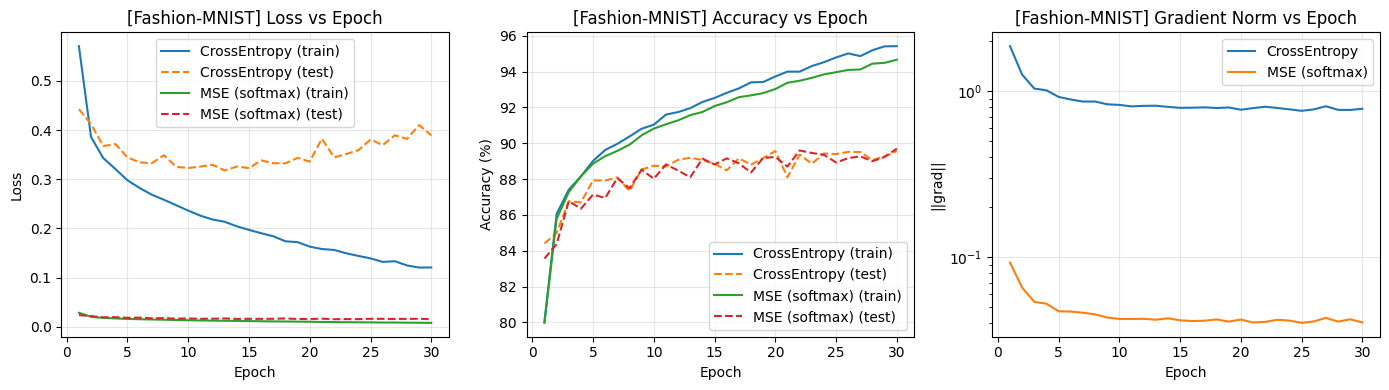

In [7]:
plot_loss_acc_curves(
    {'CrossEntropy': hist_fmnist_ce, 'MSE (softmax)': hist_fmnist_mse},
    title_prefix='[Fashion-MNIST]'
)


### 3.2 학습 초기 vs 후기 Gradient 흐름 (질문 A-3)

/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:427: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:427: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:427: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWar

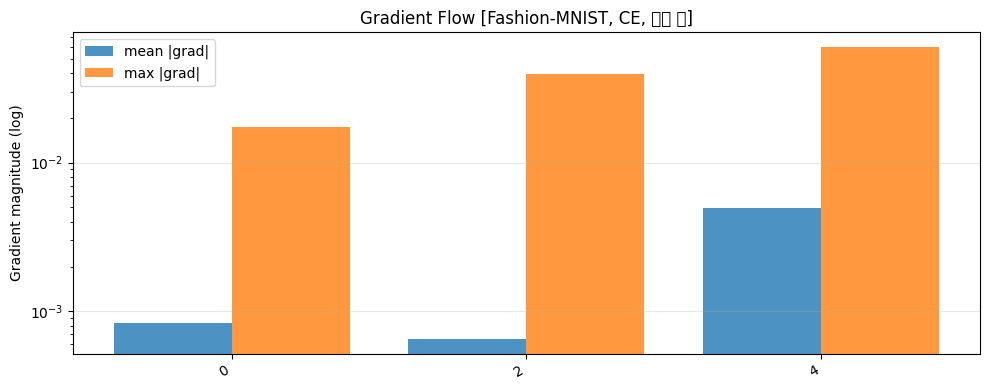

/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:427: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:427: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:427: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWar

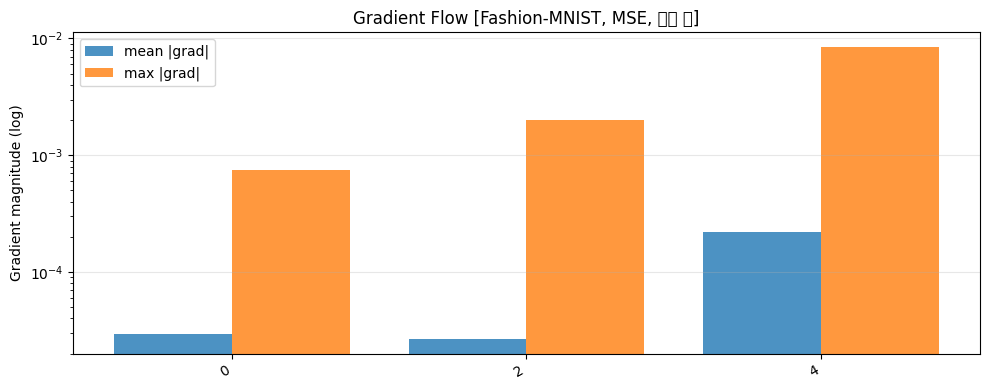

In [8]:
# 학습 초기/후기 gradient flow 비교를 위해 1배치씩 forward+backward 실행
def snapshot_gradient_flow(model, loader, loss_fn, loss_type='ce'):
    """한 배치에 대해 forward → backward → gradient 시각화."""
    model.train()
    inputs, targets = next(iter(loader))
    inputs, targets = inputs.to(device), targets.to(device)
    if inputs.dim() > 2:
        inputs = inputs.view(inputs.size(0), -1)

    logits = model(inputs)
    if loss_type == 'ce':
        loss = loss_fn(logits, targets)
    else:
        probs = torch.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets, num_classes=10).float()
        loss = loss_fn(probs, targets_oh)
    model.zero_grad()
    loss.backward()

# CE의 학습 후 gradient flow
snapshot_gradient_flow(model_ce, fmnist_train_loader, nn.CrossEntropyLoss(), 'ce')
plot_gradient_flow(model_ce, title='Gradient Flow [Fashion-MNIST, CE, 학습 후]')

# MSE의 학습 후 gradient flow
snapshot_gradient_flow(model_mse, fmnist_train_loader, nn.MSELoss(), 'mse')
plot_gradient_flow(model_mse, title='Gradient Flow [Fashion-MNIST, MSE, 학습 후]')


**해설** _(분석 가이드)_
- MSE의 마지막 레이어 gradient가 CE보다 훨씬 작은 경우, 이는 MSE의 gradient가 `(p - y) * p * (1 - p)` 형태로 softmax 출력 자체의 미분이 곱해져 작아지기 때문이다.
- CE는 `p - y`로 단순해서 출력이 wrong이어도 일정한 크기의 gradient가 흘러간다.


## 4. Digits 보조 실험

In [9]:
EPOCHS_DIGITS = 50

# CrossEntropy
set_seed(42)
model_ce_d = make_mlp(64, 10).to(device)
opt_ce_d   = torch.optim.Adam(model_ce_d.parameters(), lr=LR)
print(">>> Digits + CrossEntropy")
hist_digits_ce = fit(
    model_ce_d, digits_train_loader, digits_test_loader,
    nn.CrossEntropyLoss(), opt_ce_d, device,
    epochs=EPOCHS_DIGITS, loss_type='ce', log_every=10
)

# MSE
set_seed(42)
model_mse_d = make_mlp(64, 10).to(device)
opt_mse_d   = torch.optim.Adam(model_mse_d.parameters(), lr=LR)
print(">>> Digits + MSE (with softmax)")
hist_digits_mse = fit(
    model_mse_d, digits_train_loader, digits_test_loader,
    nn.MSELoss(), opt_mse_d, device,
    epochs=EPOCHS_DIGITS, loss_type='mse', log_every=10
)


>>> Digits + CrossEntropy
[  1/50] train_loss=2.1057 train_acc=50.87% test_loss=1.7802 test_acc=75.28% grad_norm=0.4793 lr=0.00100
[ 10/50] train_loss=0.1109 train_acc=97.15% test_loss=0.1288 test_acc=94.72% grad_norm=0.6974 lr=0.00100
[ 20/50] train_loss=0.0430 train_acc=99.37% test_loss=0.0886 test_acc=97.22% grad_norm=0.4486 lr=0.00100
[ 30/50] train_loss=0.0220 train_acc=99.79% test_loss=0.0815 test_acc=97.50% grad_norm=0.2982 lr=0.00100
[ 40/50] train_loss=0.0126 train_acc=99.86% test_loss=0.0737 test_acc=97.78% grad_norm=0.2238 lr=0.00100
[ 50/50] train_loss=0.0071 train_acc=100.00% test_loss=0.0687 test_acc=97.78% grad_norm=0.1560 lr=0.00100
>>> Digits + MSE (with softmax)
[  1/50] train_loss=0.0853 train_acc=47.18% test_loss=0.0756 test_acc=69.44% grad_norm=0.0127 lr=0.00100
[ 10/50] train_loss=0.0054 train_acc=97.22% test_loss=0.0067 test_acc=95.83% grad_norm=0.0449 lr=0.00100
[ 20/50] train_loss=0.0020 train_acc=99.30% test_loss=0.0044 test_acc=97.78% grad_norm=0.0238 lr=0.00

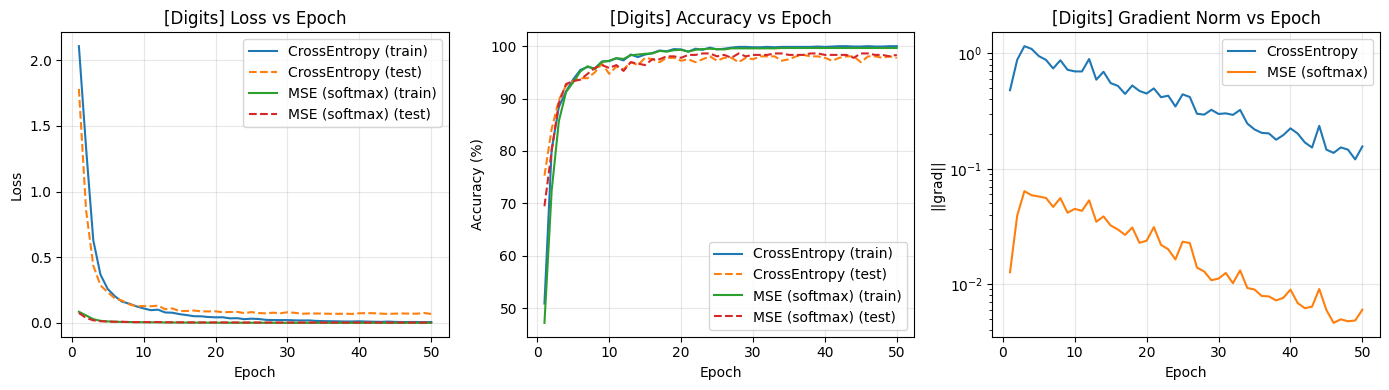

In [10]:
plot_loss_acc_curves(
    {'CrossEntropy': hist_digits_ce, 'MSE (softmax)': hist_digits_mse},
    title_prefix='[Digits]'
)


## 5. 정량 비교표

In [11]:
df = summarize_histories({
    'Fashion-MNIST / CrossEntropy': hist_fmnist_ce,
    'Fashion-MNIST / MSE':          hist_fmnist_mse,
    'Digits / CrossEntropy':        hist_digits_ce,
    'Digits / MSE':                 hist_digits_mse,
})
df


,experiment,final_test_acc(%),best_test_acc(%),min_train_loss,convergence_epoch
0,Fashion-MNIST / CrossEntropy,89.57,89.57,0.1206,28
1,Fashion-MNIST / MSE,89.70,89.70,0.0083,28
2,Digits / CrossEntropy,97.78,98.33,0.0061,49
3,Digits / MSE,98.33,98.61,0.0006,46


In [12]:
# CSV로도 저장 (보고서 표 만들기 편하게)
df.to_csv('results_A_loss.csv', index=False)
print('saved: results_A_loss.csv')


saved: results_A_loss.csv


In [15]:
# (선택) MSE without softmax 추가 실험
# logits을 그대로 one-hot에 매칭 → 학습 불안정해야 함
set_seed(42)
model_mse_nosoft = make_mlp(64, 10).to(device)
opt_msens = torch.optim.Adam(model_mse_nosoft.parameters(), lr=LR)

mse_fn = nn.MSELoss()
history_nosoft = {'train_loss': [], 'train_acc': [], 'test_loss': [],
                  'test_acc': [], 'grad_norm': [], 'lr': []}

for epoch in range(1, EPOCHS_DIGITS + 1):
    # ----- 학습 -----
    model_mse_nosoft.train()
    tl, c, t = 0, 0, 0
    for inputs, targets in digits_train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        opt_msens.zero_grad()
        logits = model_mse_nosoft(inputs)              # softmax 적용 X
        targets_oh = F.one_hot(targets, num_classes=10).float()
        loss = mse_fn(logits, targets_oh)              # logits vs one-hot 직접 비교
        loss.backward()
        opt_msens.step()
        tl += loss.item() * inputs.size(0)
        c  += (logits.argmax(dim=1) == targets).sum().item()
        t  += inputs.size(0)
    history_nosoft['train_loss'].append(tl / t)
    history_nosoft['train_acc'].append(100 * c / t)

    # ----- 평가 (MSE는 손실 그대로 계산, accuracy는 argmax로) -----
    model_mse_nosoft.eval()
    te_tl, te_c, te_t = 0, 0, 0
    with torch.no_grad():
        for inputs, targets in digits_test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits = model_mse_nosoft(inputs)
            targets_oh = F.one_hot(targets, num_classes=10).float()
            loss = mse_fn(logits, targets_oh)
            te_tl += loss.item() * inputs.size(0)
            te_c  += (logits.argmax(dim=1) == targets).sum().item()
            te_t  += inputs.size(0)
    history_nosoft['test_loss'].append(te_tl / te_t)
    history_nosoft['test_acc'].append(100 * te_c / te_t)
    history_nosoft['grad_norm'].append(0)
    history_nosoft['lr'].append(LR)

print(f"MSE-no-softmax 최종 train_acc: {history_nosoft['train_acc'][-1]:.2f}%, "
      f"test_acc: {history_nosoft['test_acc'][-1]:.2f}%")
print(f"MSE+softmax   최종 train_acc: {hist_digits_mse['train_acc'][-1]:.2f}%, "
      f"test_acc: {hist_digits_mse['test_acc'][-1]:.2f}%")
print(f"CrossEntropy  최종 train_acc: {hist_digits_ce['train_acc'][-1]:.2f}%, "
      f"test_acc: {hist_digits_ce['test_acc'][-1]:.2f}%")

MSE-no-softmax 최종 train_acc: 100.00%, test_acc: 98.61%
MSE+softmax   최종 train_acc: 99.65%, test_acc: 98.33%
CrossEntropy  최종 train_acc: 100.00%, test_acc: 97.78%
